# Reabastecimento de Estoque com Base no Histórico de Compras

Pipeline completo de forecasting de demanda usando o dataset **Store Item Demand Forecasting** do Kaggle.

**Etapas:**
1. Configuração do ambiente
2. Carregamento dos dados (com download automático)
3. Análise exploratória
4. Criação de atributos (feature engineering)
5. Divisão temporal
6. Treinamento de modelos
7. Pipeline completo
8. Visualização dos resultados

## Configuração do Ambiente

Instala dependências e importa as bibliotecas necessárias.

In [1]:
# Instalar dependências (caso necessário)
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
# Bibliotecas
from fastapi import FastAPI
import pandas as pd
import numpy as np
import os
import zipfile
import urllib.request
import matplotlib.pyplot as plt
import warnings
import joblib
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from scipy.stats import wilcoxon
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados

Tenta carregar o arquivo `train.csv` localmente. Caso não encontre, baixa automaticamente do Kaggle.

**Dataset:** [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only)

> Para o download automático funcionar no Colab, você precisa fazer upload do arquivo `kaggle.json`  
> (disponível em: kaggle.com → Account → API → Create New Token)

In [3]:
import os
import urllib.request
import pandas as pd

DATASET_PATH = "train.csv"
URL_DATASET = ("https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data?select=test.csv")

def baixar_dataset():


def carregar_dataset(caminho):
    if os.path.exists(DATASET_PATH):
        print("Dataset já existe.")
        return

    print("Baixando dataset...")
    urllib.request.urlretrieve(
        URL_DATASET,
        DATASET_PATH
    )

    if not os.path.exists(caminho):
        baixar_dataset()

    df = pd.read_csv(caminho)
    print(f"Shape: {df.shape}")
    return df

df = carregar_dataset(DATASET_PATH)

Arquivo 'train.csv' encontrado localmente.
Dataset carregado! (encoding=utf-8, sep=',')
Shape: 774,412 linhas × 4 colunas


### 1.1 Verificação Inicial dos Dados

In [18]:
if df is not None:
    print("=" * 50)
    print("INFORMAÇÕES DO DATASET")
    print("=" * 50)
    df.info()

    print("\n" + "=" * 50)
    print("ESTATÍSTICAS DESCRITIVAS")
    print("=" * 50)
    display(df.describe())

    print("\n" + "=" * 50)
    print("VALORES NULOS POR COLUNA")
    print("=" * 50)
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado!")

    print("\n" + "=" * 50)
    print("PRIMEIRAS LINHAS")
    print("=" * 50)
    display(df.head())
else:
    print("DataFrame não carregado. Execute a célula anterior primeiro.")

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774412 entries, 0 to 774411
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       774412 non-null  datetime64[ns]
 1   store      774412 non-null  int64         
 2   item       774412 non-null  int64         
 3   sales      774412 non-null  int64         
 4   dayofweek  774412 non-null  int32         
 5   month      774412 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(3)
memory usage: 29.5 MB

ESTATÍSTICAS DESCRITIVAS


,date,store,item,sales,dayofweek,month
count,774412,774412.000000,774412.000000,774412.000000,774412.000000,774412.000000
mean,2015-07-02 07:13:41.571979776,5.471584,21.708000,52.977021,3.001646,6.522848
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000,0.000000,1.000000
25%,2014-04-02 00:00:00,3.000000,11.000000,30.000000,1.000000,4.000000
50%,2015-07-02 00:00:00,5.000000,22.000000,48.000000,3.000000,7.000000
75%,2016-10-01 00:00:00,8.000000,32.000000,71.000000,5.000000,10.000000
max,2017-12-31 00:00:00,10.000000,43.000000,231.000000,6.000000,12.000000
std,NaN,2.875087,12.244357,29.130498,1.999314,3.448524



VALORES NULOS POR COLUNA
Nenhum valor nulo encontrado!

PRIMEIRAS LINHAS


,date,store,item,sales,dayofweek,month
0,2013-01-01,1,1,13,1,1
1,2013-01-02,1,1,11,2,1
2,2013-01-03,1,1,14,3,1
3,2013-01-04,1,1,13,4,1
4,2013-01-05,1,1,10,5,1


## 2. Análise Exploratória dos Dados (EDA)

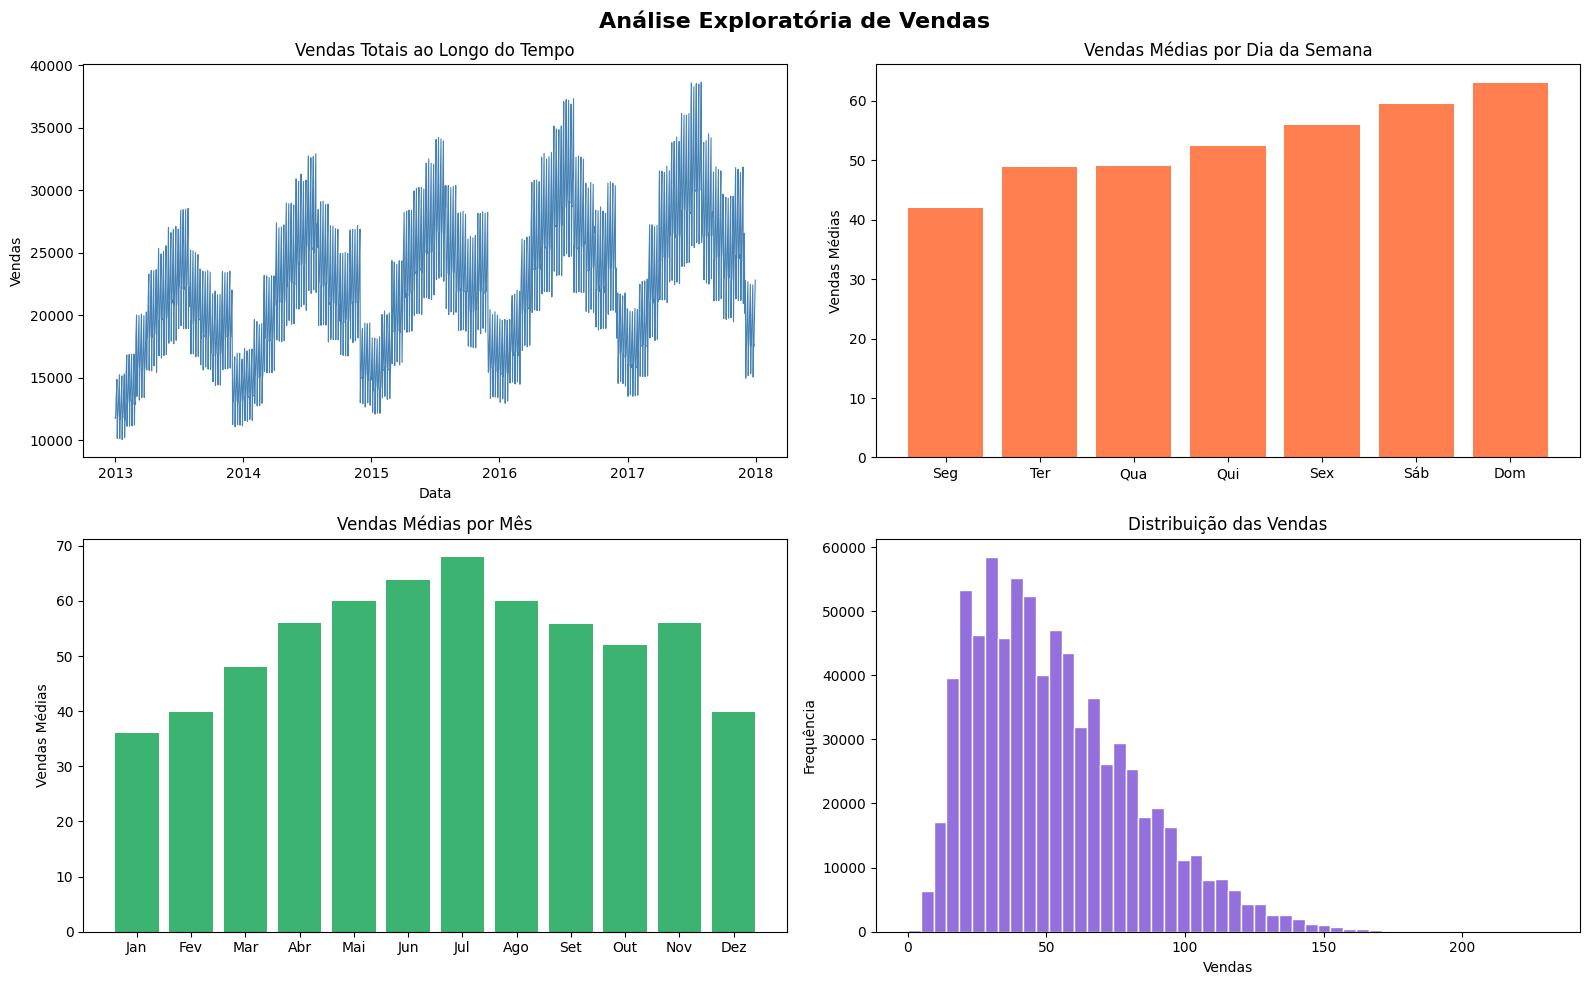


Período: 2013-01-01 até 2017-12-31
Lojas: 10
Itens: 43
Média de vendas: 52.98
Vendas mín/máx: 0 / 231


In [5]:
if df is not None:
    df['date'] = pd.to_datetime(df['date'])

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Análise Exploratória de Vendas', fontsize=16, fontweight='bold')

    # 1. Vendas totais ao longo do tempo
    vendas_tempo = df.groupby('date')['sales'].sum()
    axes[0, 0].plot(vendas_tempo.index, vendas_tempo.values, linewidth=0.8, color='steelblue')
    axes[0, 0].set_title('Vendas Totais ao Longo do Tempo')
    axes[0, 0].set_xlabel('Data')
    axes[0, 0].set_ylabel('Vendas')

    # 2. Vendas por dia da semana
    df['dayofweek'] = df['date'].dt.dayofweek
    vendas_semana = df.groupby('dayofweek')['sales'].mean()
    dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
    axes[0, 1].bar(dias, vendas_semana.values, color='coral')
    axes[0, 1].set_title('Vendas Médias por Dia da Semana')
    axes[0, 1].set_ylabel('Vendas Médias')

    # 3. Vendas por mês
    df['month'] = df['date'].dt.month
    vendas_mes = df.groupby('month')['sales'].mean()
    meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
    axes[1, 0].bar(meses, vendas_mes.values, color='mediumseagreen')
    axes[1, 0].set_title('Vendas Médias por Mês')
    axes[1, 0].set_ylabel('Vendas Médias')

    # 4. Distribuição das vendas
    axes[1, 1].hist(df['sales'], bins=50, color='mediumpurple', edgecolor='white')
    axes[1, 1].set_title('Distribuição das Vendas')
    axes[1, 1].set_xlabel('Vendas')
    axes[1, 1].set_ylabel('Frequência')

    plt.tight_layout()
    plt.show()

    print(f"\nPeríodo: {df['date'].min().date()} até {df['date'].max().date()}")
    print(f"Lojas: {df['store'].nunique()}")
    print(f"Itens: {df['item'].nunique()}")
    print(f"Média de vendas: {df['sales'].mean():.2f}")
    print(f"Vendas mín/máx: {df['sales'].min()} / {df['sales'].max()}")

## 3. Criação de Atributos (Feature Engineering)

- **Temporais:** dia, mês, dia da semana, semana do ano
- **Lags:** valores de vendas passados (1, 7 e 30 dias)
- **Médias móveis:** média dos últimos 7 e 30 dias
- **Tendência:** diferença entre lag_1 e lag_7

In [6]:
def criar_features(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # --- Features temporais ---
    df['day']        = df['date'].dt.day
    df['month']      = df['date'].dt.month
    df['year']       = df['date'].dt.year
    df['dayofweek']  = df['date'].dt.dayofweek
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['quarter']    = df['date'].dt.quarter

    # --- Ordenação essencial para lags correrem por grupo ---
    df = df.sort_values(['store', 'item', 'date']).reset_index(drop=True)

    grupo = df.groupby(['store', 'item'])['sales']

    # --- Lags ---
    df['lag_1']  = grupo.shift(1)
    df['lag_7']  = grupo.shift(7)
    df['lag_30'] = grupo.shift(30)

    # --- Médias móveis (shift(1) evita data leakage) ---
    df['rolling_mean_7']  = grupo.shift(1).rolling(7).mean()
    df['rolling_mean_30'] = grupo.shift(1).rolling(30).mean()
    df['rolling_std_7']   = grupo.shift(1).rolling(7).std()

    # --- Tendência: diferença entre lag_1 e lag_7 ---
    df['trend'] = df['lag_1'] - df['lag_7']

    df = df.dropna().reset_index(drop=True)

    print(f"Features criadas! Shape final: {df.shape}")
    print(f"   Colunas: {list(df.columns)}")
    return df

## 4. Divisão Temporal dos Dados

**Importante:** nunca embaralhar dados de séries temporais.  
O treino usa dados **anteriores** ao corte; o teste usa dados **posteriores**.

In [7]:
def split_temporal(df, data_corte='2017-01-01'):
    """
    Divide respeitando a ordem cronológica.
    Treino: antes do corte | Teste: a partir do corte.
    """
    train = df[df['date'] < data_corte].copy()
    test  = df[df['date'] >= data_corte].copy()

    pct_treino = len(train) / len(df) * 100
    print(f"Split temporal em '{data_corte}'")
    print(f"Treino: {len(train):,} amostras ({pct_treino:.1f}%)")
    print(f"Teste:  {len(test):,} amostras ({100 - pct_treino:.1f}%)")
    print(f"Período treino: {train['date'].min().date()} → {train['date'].max().date()}")
    print(f"Período teste:  {test['date'].min().date()} → {test['date'].max().date()}")

    return train, test

## 5. Treinamento de Modelos

Três algoritmos são testados e comparados por **RMSE** e **SMAPE**.

- **SMAPE** (Symmetric Mean Absolute Percentage Error) é ideal para reabastecimento pois compara itens em escalas diferentes de forma justa.
- **RMSE** penaliza erros grandes — bom para evitar rupturas de estoque.

In [8]:
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominador != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominador[mask]) * 100

mlflow.set_experiment("Previsao_Estoque")

def treinar_modelos(X_train, y_train, X_test, y_test):

    modelos = {
        "LinearRegression": LinearRegression(),
        "RandomForest": RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42
        ),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        )
    }

    resultados = {}

    print(f"{'Modelo':<20} {'MAE':>10} {'RMSE':>10} {'SMAPE':>10}")
    print("-" * 60)

    for nome, modelo in modelos.items():

        with mlflow.start_run(run_name=nome):

            modelo.fit(X_train, y_train)

            pred = modelo.predict(X_test)
            pred = np.clip(pred, 0, None)

            mae_val = mean_absolute_error(y_test, pred)
            rmse_val = np.sqrt(mean_squared_error(y_test, pred))
            smape_val = smape(y_test, pred)
            r2_val = r2_score(y_test, pred)

            mlflow.log_param("modelo", nome)

            if hasattr(modelo, "n_estimators"):
                mlflow.log_param("n_estimators", modelo.n_estimators)

            mlflow.log_metric("MAE", mae_val)
            mlflow.log_metric("RMSE", rmse_val)
            mlflow.log_metric("SMAPE", smape_val)
            mlflow.log_metric("R2", r2_val)

            mlflow.sklearn.log_model(modelo, "modelo")

            resultados[nome] = {
                "modelo": modelo,
                "pred": pred,
                "MAE": mae_val,
                "RMSE": rmse_val,
                "SMAPE": smape_val,
                "R2": r2_val
            }

            print(
                f"{nome:<20} "
                f"{mae_val:>10.2f} "
                f"{rmse_val:>10.2f} "
                f"{smape_val:>9.2f}%"
                f"{r2_val:>9.4f}"
            )

    print("\nResumo dos Modelos")

    df_metricas = pd.DataFrame([
          {
              "Modelo": nome,
              "MAE": round(dados["MAE"], 2),
              "RMSE": round(dados["RMSE"], 2),
              "SMAPE (%)": round(dados["SMAPE"], 2),
              "R²": round(dados["R2"], 4)
          }
          for nome, dados in resultados.items()
      ]).sort_values(by="RMSE")

    display(df_metricas)

    melhor_modelo = df_metricas.iloc[0]["Modelo"]

    print(f"\nMelhor modelo selecionado: {melhor_modelo}")


    return resultados

2026/06/16 14:41:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/16 14:41:14 INFO mlflow.store.db.utils: Updating database tables
2026/06/16 14:41:19 INFO mlflow.tracking.fluent: Experiment with name 'Previsao_Estoque' does not exist. Creating a new experiment.


## 6. Pipeline Completo

Executa todas as etapas em sequência e retorna o melhor modelo (menor SMAPE).

In [9]:
FEATURES = [
    'day', 'month', 'year', 'dayofweek', 'weekofyear',
    'is_weekend', 'quarter',
    'lag_1', 'lag_7', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7',
    'trend'
]


def pipeline_completo(df, data_corte='2017-01-01'):
    print("\n" + "=" * 48)
    print("ETAPA 1 — Feature Engineering")
    print("=" * 48)
    df_feat = criar_features(df)

    print("\n" + "=" * 48)
    print("ETAPA 2 — Split Temporal")
    print("=" * 48)
    train, test = split_temporal(df_feat, data_corte)

    X_train = train[FEATURES]
    y_train = train['sales']
    X_test  = test[FEATURES]
    y_test  = test['sales']

    print("\n" + "=" * 48)
    print("ETAPA 3 — Treinamento")
    print("=" * 48)
    resultados = treinar_modelos(X_train, y_train, X_test, y_test)

    melhor_nome, melhor = min(resultados.items(), key=lambda x: x[1]['SMAPE'])
    print(f"\nMelhor modelo: {melhor_nome} (SMAPE={melhor['SMAPE']:.2f}%)")

    return melhor['modelo'], melhor['pred'], X_test, y_test, test, resultados

## 7. Execução e Visualização dos Resultados


ETAPA 1 — Feature Engineering
Features criadas! Shape final: (761662, 18)
   Colunas: ['date', 'store', 'item', 'sales', 'dayofweek', 'month', 'day', 'year', 'weekofyear', 'is_weekend', 'quarter', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'trend']

ETAPA 2 — Split Temporal
Split temporal em '2017-01-01'
Treino: 606,902 amostras (79.7%)
Teste:  154,760 amostras (20.3%)
Período treino: 2013-01-31 → 2016-12-31
Período teste:  2017-01-01 → 2017-12-31

ETAPA 3 — Treinamento
Modelo                      MAE       RMSE      SMAPE
------------------------------------------------------------


2026/06/16 16:31:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 16:31:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LinearRegression           7.13       9.32     14.03%   0.9147


2026/06/16 16:39:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 16:39:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest               6.54       8.57     12.60%   0.9278


2026/06/16 16:48:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 16:48:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


GradientBoosting           6.22       8.08     12.12%   0.9359

Resumo dos Modelos


,Modelo,MAE,RMSE,SMAPE (%),R²
2,GradientBoosting,6.22,8.08,12.12,0.9359
1,RandomForest,6.54,8.57,12.60,0.9278
0,LinearRegression,7.13,9.32,14.03,0.9147



Melhor modelo selecionado: GradientBoosting

Melhor modelo: GradientBoosting (SMAPE=12.12%)


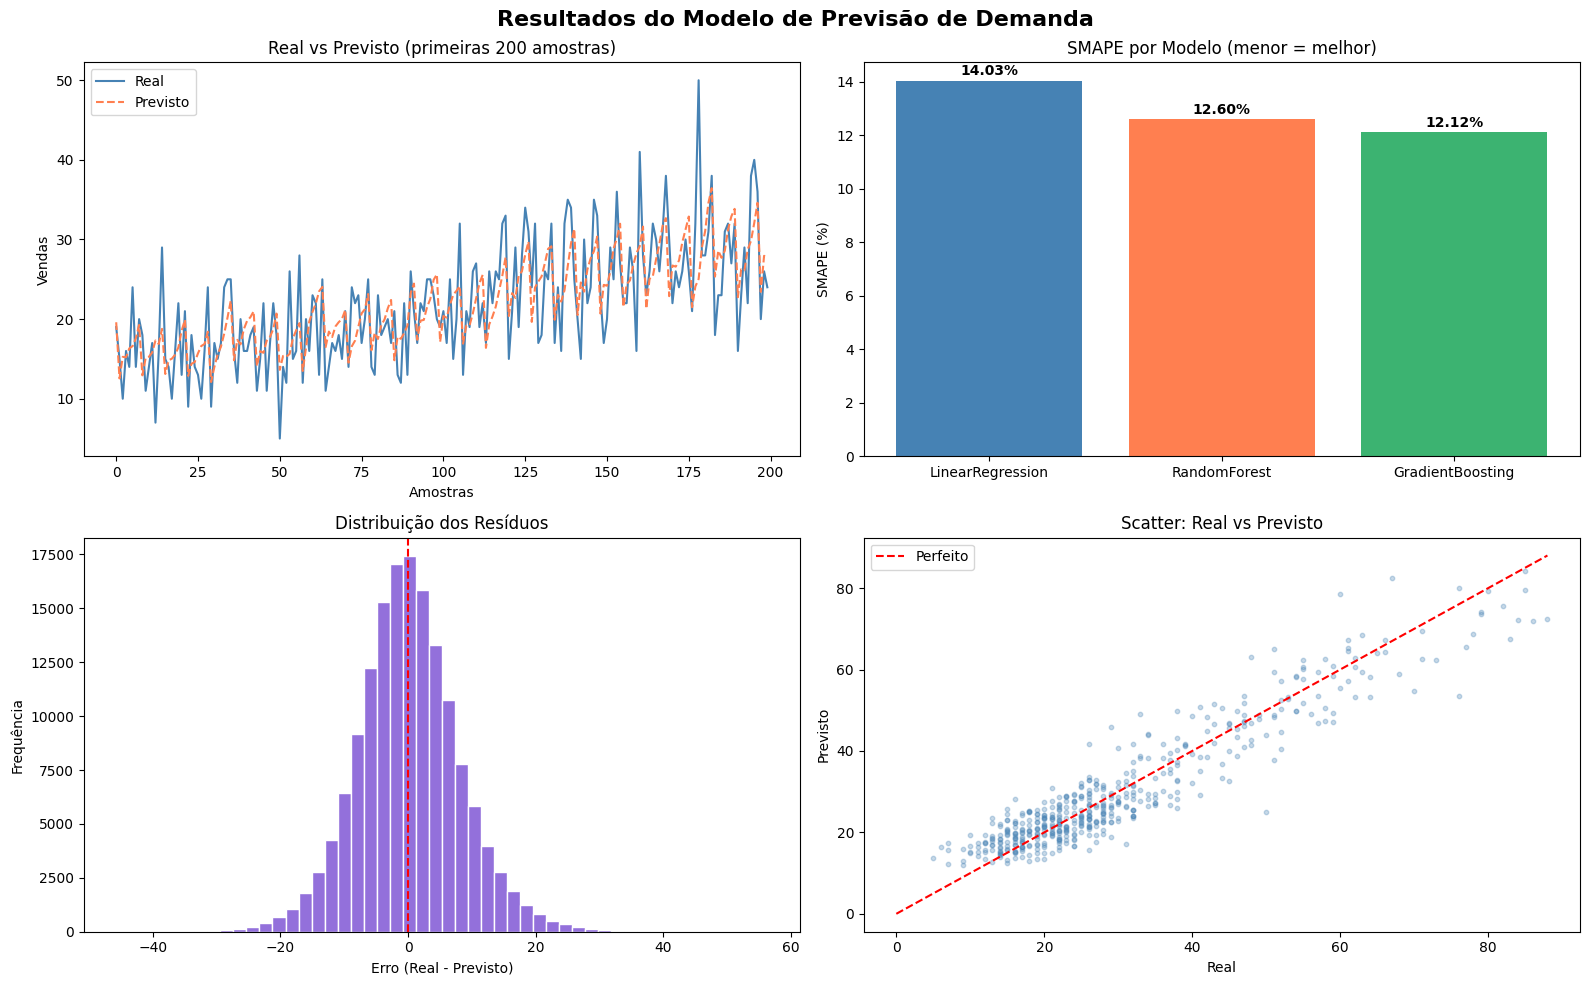


Modelo salvo em 'models/modelo.pkl'


In [19]:
def plot_resultados(y_test, pred, test_df, resultados):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Resultados do Modelo de Previsão de Demanda', fontsize=16, fontweight='bold')

    # 1. Real vs Previsto (primeiras 200 amostras)
    axes[0, 0].plot(y_test.values[:200], label='Real', linewidth=1.5, color='steelblue')
    axes[0, 0].plot(pred[:200], label='Previsto', linewidth=1.5, color='coral', linestyle='--')
    axes[0, 0].set_title('Real vs Previsto (primeiras 200 amostras)')
    axes[0, 0].set_xlabel('Amostras')
    axes[0, 0].set_ylabel('Vendas')
    axes[0, 0].legend()

    # 2. Comparação de métricas entre modelos
    nomes  = list(resultados.keys())
    smapes = [resultados[n]['SMAPE'] for n in nomes]
    bars = axes[0, 1].bar(nomes, smapes, color=['steelblue', 'coral', 'mediumseagreen'])
    axes[0, 1].set_title('SMAPE por Modelo (menor = melhor)')
    axes[0, 1].set_ylabel('SMAPE (%)')
    for bar, val in zip(bars, smapes):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

    # 3. Distribuição dos resíduos
    residuos = y_test.values - pred
    axes[1, 0].hist(residuos, bins=50, color='mediumpurple', edgecolor='white')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1, 0].set_title('Distribuição dos Resíduos')
    axes[1, 0].set_xlabel('Erro (Real - Previsto)')
    axes[1, 0].set_ylabel('Frequência')

    # 4. Real vs Previsto (scatter)
    axes[1, 1].scatter(y_test.values[:500], pred[:500], alpha=0.3, color='steelblue', s=10)
    lim = max(y_test.values[:500].max(), pred[:500].max())
    axes[1, 1].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfeito')
    axes[1, 1].set_title('Scatter: Real vs Previsto')
    axes[1, 1].set_xlabel('Real')
    axes[1, 1].set_ylabel('Previsto')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


# --- Execução ---
if df is not None:
    modelo, pred, X_test, y_test, test_df, resultados = pipeline_completo(df)
    plot_resultados(y_test, pred, test_df, resultados)
    output_dir = "models"
    os.makedirs(output_dir, exist_ok=True)
    joblib.dump(modelo, os.path.join(output_dir, "modelo.pkl"))
    print(f"\nModelo salvo em '{os.path.join(output_dir, 'modelo.pkl')}'")

else:
    print("Carregue o dataset antes de executar o pipeline.")

## 8. Sugestão de Reabastecimento

Com base nas previsões, calcula a quantidade sugerida de reabastecimento por loja e item para os próximos 7 dias.

In [11]:
def sugerir_reabastecimento(modelo, df, dias_futuros=7, margem_seguranca=0.15):
    """
    Gera sugestão de quantidade a repor por loja/item.
    margem_seguranca: % extra sobre a previsão para evitar ruptura de estoque.
    """
    df_feat = criar_features(df)

    # Pega os dados mais recentes de cada loja/item
    ultimo_dia = df_feat.groupby(['store', 'item']).tail(1).copy()

    X_futuro = ultimo_dia[FEATURES]
    previsao = modelo.predict(X_futuro)
    previsao = np.clip(previsao, 0, None)

    ultimo_dia['previsao_diaria']  = previsao
    ultimo_dia['previsao_7dias']   = previsao * dias_futuros
    ultimo_dia['sugestao_repor']   = np.ceil(previsao * dias_futuros * (1 + margem_seguranca))

    resultado = ultimo_dia[['store', 'item', 'previsao_diaria', 'previsao_7dias', 'sugestao_repor']]
    resultado = resultado.sort_values(['store', 'item']).reset_index(drop=True)

    print(f"\nSugestão de Reabastecimento (próximos {dias_futuros} dias)")
    print(f"   Margem de segurança: {margem_seguranca*100:.0f}%")
    print()
    display(resultado.head(20))

    return resultado


if df is not None:
    reabastecimento = sugerir_reabastecimento(modelo, df)

Features criadas! Shape final: (761662, 18)
   Colunas: ['date', 'store', 'item', 'sales', 'dayofweek', 'month', 'day', 'year', 'weekofyear', 'is_weekend', 'quarter', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'trend']

Sugestão de Reabastecimento (próximos 7 dias)
   Margem de segurança: 15%



,store,item,previsao_diaria,previsao_7dias,sugestao_repor
0,1,1,19.982307,139.876146,161.0
1,1,2,54.372374,380.606620,438.0
2,1,3,30.758078,215.306547,248.0
3,1,4,19.087760,133.614317,154.0
4,1,5,16.516309,115.614165,133.0
5,1,6,52.156936,365.098550,420.0
6,1,7,50.619946,354.339621,408.0
7,1,8,67.769792,474.388541,546.0
8,1,9,42.709754,298.968275,344.0
9,1,10,69.483969,486.387782,560.0


## 9. Rastreamento de Experimentos com MLflow

Os experimentos são registrados automaticamente durante o treinamento.

Após executar o notebook, utilize:

```python
!mlflow ui
```

para visualizar métricas, parâmetros e modelos registrados.


## 10. Disponibilização do Modelo com FastAPI

Após o treinamento, o modelo pode ser disponibilizado por meio de uma API REST.


In [20]:
app = FastAPI()

modelo = joblib.load("models/modelo.pkl")

@app.get("/")
def home():
    return {"status": "API funcionando"}

@app.post("/predict")
def predict(features: dict):

    df = pd.DataFrame([features])

    previsao = modelo.predict(df)

    return {
        "previsao": float(previsao[0])
    }

## 11. Containerização com Docker

Para garantir a reprodução do ambiente, o projeto pode ser executado em um contêiner Docker.

```dockerfile
FROM python:3.11-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 8000

CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]
```


## 11.1. Docker Compose
O arquivo docker-compose.yml para automatizar a execução do projeto.
```yaml
version: '3.9'

services:
  estoque-api:
    build: .
    container_name: estoque-api
    ports:
      - "8000:8000"
    volumes:
      - .:/app
```

## Teste Estatístico (Wilcoxon)

Esta etapa compara os dois melhores modelos utilizando o teste de Wilcoxon sobre os erros absolutos das previsões.
Um p-valor menor que 0.05 indica diferença estatisticamente significativa entre os modelos.


In [21]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

def comparar_modelos(resultados, y_test):
    df_metricas = pd.DataFrame([
        {
            "Modelo": nome,
            "RMSE": dados["RMSE"]
        }
        for nome, dados in resultados.items()
    ]).sort_values("RMSE")

    modelo_1 = df_metricas.iloc[0]["Modelo"]
    modelo_2 = df_metricas.iloc[1]["Modelo"]

    print(f"Comparando modelos: {modelo_1} vs {modelo_2}")

    erro_1 = np.abs(
        y_test.values - resultados[modelo_1]["pred"]
    )

    erro_2 = np.abs(
        y_test.values - resultados[modelo_2]["pred"]
    )

    stat, p_value = wilcoxon(
        erro_1,
        erro_2
    )

    print(f"Estatística de Wilcoxon: {stat:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print(
            "Diferença estatisticamente significativa entre os modelos."
        )
    else:
        print(
            "Não foi encontrada diferença estatisticamente significativa."
        )

    return stat, p_value